# 05 - Modeling

Trains and evaluates two models for binary sentiment classification:
- Logistic Regression (baseline)
- Random Forest (improved)

Both models use `class_weight='balanced'` to handle class imbalance (73% positive).

**Prerequisite:** Run `04_split.ipynb` first.

## 1. Setup

In [1]:
import boto3, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

with open('project_config.json') as f:
    cfg = json.load(f)

REGION        = cfg['REGION']
SOURCE_BUCKET = cfg['SOURCE_BUCKET']
FEATURE_COLS  = cfg['FEATURE_COLS']
TARGET_COL    = cfg['TARGET_COL']
RANDOM_STATE  = cfg['RANDOM_STATE']

session = boto3.Session(region_name=REGION)
s3      = session.client('s3')

sns.set_theme(style='whitegrid')
print(f'Feature cols : {FEATURE_COLS}')
print(f'Target col   : {TARGET_COL}')

Feature cols : ['review_length', 'word_count', 'useful', 'funny', 'cool', 'vader_score']
Target col   : sentiment


## 2. Load Splits from S3

In [2]:
def load_split(split_name):
    local_path = f'/tmp/{split_name}.parquet'
    s3.download_file(SOURCE_BUCKET, f'splits/{split_name}.parquet', local_path)
    return pd.read_parquet(local_path)

train_data = load_split('train')
test_data  = load_split('test')
val_data   = load_split('validation')
prod_data  = load_split('production')

print('Split sizes:')
for name, df in [('Train', train_data), ('Test', test_data),
                 ('Validation', val_data), ('Production', prod_data)]:
    print(f'  {name:<12}: {len(df):,} rows  (positive rate: {df[TARGET_COL].mean()*100:.1f}%)')

Split sizes:
  Train       : 61,290 rows  (positive rate: 73.5%)
  Test        : 15,300 rows  (positive rate: 73.5%)
  Validation  : 15,300 rows  (positive rate: 73.5%)
  Production  : 93,165 rows  (positive rate: 71.4%)


## 3. Prepare Features

In [3]:
X_train = train_data[FEATURE_COLS]
y_train = train_data[TARGET_COL]

X_val   = val_data[FEATURE_COLS]
y_val   = val_data[TARGET_COL]

X_test  = test_data[FEATURE_COLS]
y_test  = test_data[TARGET_COL]

X_prod  = prod_data[FEATURE_COLS]
y_prod  = prod_data[TARGET_COL]

# Scale features — required for logistic regression
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
X_prod_scaled  = scaler.transform(X_prod)

print(f'Train shape : {X_train.shape}')
print(f'Val shape   : {X_val.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Prod shape  : {X_prod.shape}')

Train shape : (61290, 6)
Val shape   : (15300, 6)
Test shape  : (15300, 6)
Prod shape  : (93165, 6)


## 4. Logistic Regression (Baseline)

In [4]:
print('Training Logistic Regression...')
lr = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)
lr.fit(X_train_scaled, y_train)
print('Done')

# Evaluate on validation set
y_val_pred_lr    = lr.predict(X_val_scaled)
y_val_prob_lr    = lr.predict_proba(X_val_scaled)[:, 1]

print('\nValidation results:')
print(classification_report(y_val, y_val_pred_lr, target_names=['Negative', 'Positive']))

Training Logistic Regression...
Done

Validation results:
              precision    recall  f1-score   support

    Negative       0.80      0.83      0.82      4058
    Positive       0.94      0.93      0.93     11242

    accuracy                           0.90     15300
   macro avg       0.87      0.88      0.87     15300
weighted avg       0.90      0.90      0.90     15300



## 5. Random Forest

In [5]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Done')

# Evaluate on validation set
y_val_pred_rf = rf.predict(X_val)
y_val_prob_rf = rf.predict_proba(X_val)[:, 1]

print('\nValidation results:')
print(classification_report(y_val, y_val_pred_rf, target_names=['Negative', 'Positive']))

Training Random Forest...


Done

Validation results:
              precision    recall  f1-score   support

    Negative       0.83      0.80      0.82      4058
    Positive       0.93      0.94      0.94     11242

    accuracy                           0.90     15300
   macro avg       0.88      0.87      0.88     15300
weighted avg       0.90      0.90      0.90     15300



## 6. Compare Models on Validation Set

In [6]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_prob)
    }

lr_metrics = get_metrics(y_val, y_val_pred_lr, y_val_prob_lr)
rf_metrics = get_metrics(y_val, y_val_pred_rf, y_val_prob_rf)

results = pd.DataFrame([lr_metrics, rf_metrics],
                        index=['Logistic Regression', 'Random Forest'])

print('Validation metrics:')
print(results.round(4).to_string())

best_model_name = results['f1'].idxmax()
print(f'\nBest model by F1: {best_model_name}')

Validation metrics:
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9005     0.9372  0.9266  0.9319   0.9499
Random Forest          0.9040     0.9290  0.9413  0.9351   0.9497

Best model by F1: Random Forest


## 7. Confusion Matrices and ROC Curves

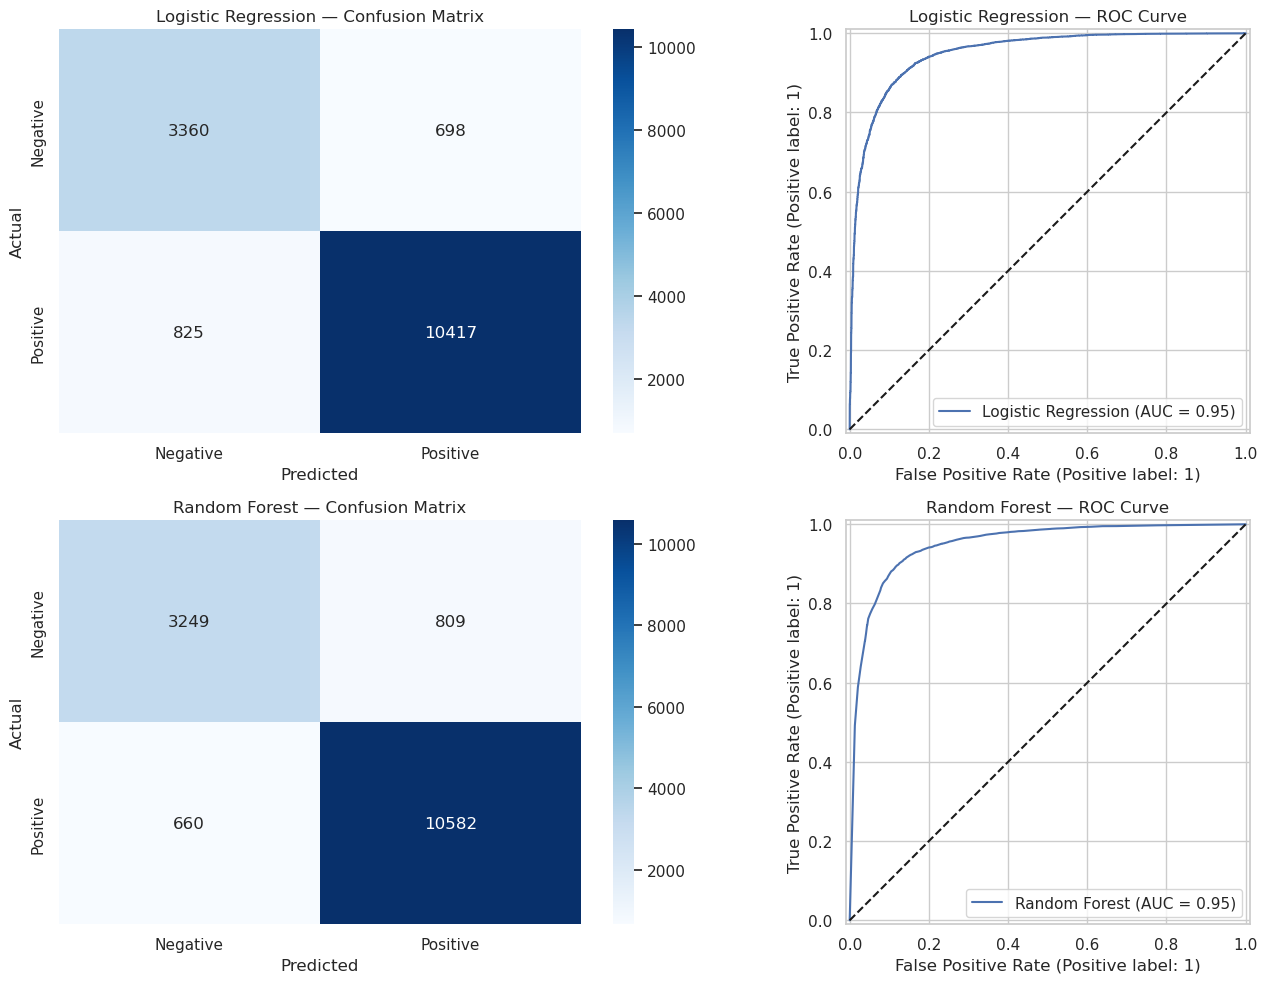

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [
    ('Logistic Regression', y_val_pred_lr, y_val_prob_lr, lr),
    ('Random Forest',       y_val_pred_rf, y_val_prob_rf, rf)
]

for i, (name, y_pred, y_prob, model) in enumerate(models):
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i][0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i][0].set_title(f'{name} — Confusion Matrix')
    axes[i][0].set_ylabel('Actual')
    axes[i][0].set_xlabel('Predicted')

    # ROC curve
    RocCurveDisplay.from_predictions(y_val, y_prob, ax=axes[i][1], name=name)
    axes[i][1].set_title(f'{name} — ROC Curve')
    axes[i][1].plot([0, 1], [0, 1], 'k--')

plt.tight_layout()
plt.savefig('modeling_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Feature Importance

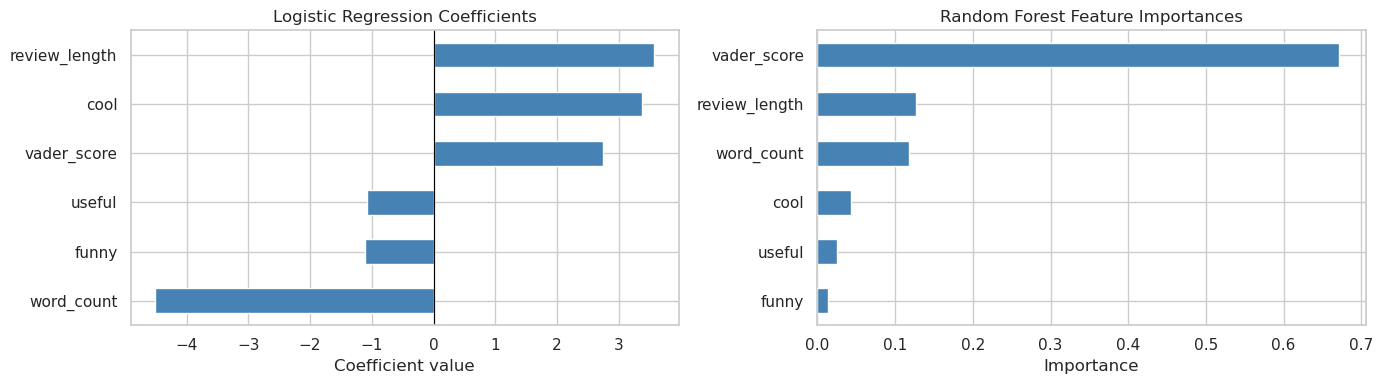

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Logistic Regression coefficients
lr_coefs = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values()
lr_coefs.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression Coefficients')
axes[0].set_xlabel('Coefficient value')
axes[0].axvline(0, color='black', linewidth=0.8)

# Random Forest feature importances
rf_importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
rf_importance.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('modeling_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Final Evaluation on Test Set

Run once on the best model — do not use test set for tuning.

In [9]:
# Pick best model based on validation F1
if rf_metrics['f1'] >= lr_metrics['f1']:
    best_model  = rf
    best_name   = 'Random Forest'
    X_test_final = X_test
    X_prod_final = X_prod
else:
    best_model  = lr
    best_name   = 'Logistic Regression'
    X_test_final = X_test_scaled
    X_prod_final = X_prod_scaled

print(f'Best model: {best_name}')

# Test set evaluation
y_test_pred = best_model.predict(X_test_final)
y_test_prob = best_model.predict_proba(X_test_final)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_prob)

print('\nTest set results:')
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))
print(f'ROC-AUC: {test_metrics["roc_auc"]:.4f}')

Best model: Random Forest



Test set results:
              precision    recall  f1-score   support

    Negative       0.84      0.81      0.82      4057
    Positive       0.93      0.95      0.94     11243

    accuracy                           0.91     15300
   macro avg       0.89      0.88      0.88     15300
weighted avg       0.91      0.91      0.91     15300

ROC-AUC: 0.9539


## 10. Production Data Evaluation

Evaluates best model on 2020-2022 reviews — simulates real deployment.

In [10]:
y_prod_pred = best_model.predict(X_prod_final)
y_prod_prob = best_model.predict_proba(X_prod_final)[:, 1]
prod_metrics = get_metrics(y_prod, y_prod_pred, y_prod_prob)

print(f'Production results ({best_name} on 2020-2022 data):')
print(classification_report(y_prod, y_prod_pred, target_names=['Negative', 'Positive']))
print(f'ROC-AUC: {prod_metrics["roc_auc"]:.4f}')

# Compare test vs production
comparison = pd.DataFrame([test_metrics, prod_metrics],
                           index=['Test (2019)', 'Production (2020-2022)'])
print('\nTest vs Production:')
print(comparison.round(4).to_string())

Production results (Random Forest on 2020-2022 data):
              precision    recall  f1-score   support

    Negative       0.86      0.82      0.84     26610
    Positive       0.93      0.95      0.94     66555

    accuracy                           0.91     93165
   macro avg       0.89      0.88      0.89     93165
weighted avg       0.91      0.91      0.91     93165

ROC-AUC: 0.9577

Test vs Production:
                        accuracy  precision  recall      f1  roc_auc
Test (2019)               0.9088     0.9316  0.9454  0.9384   0.9539
Production (2020-2022)    0.9095     0.9293  0.9453  0.9372   0.9577


## 11. Summary

In [11]:
print('=== Modeling Summary ===')
print(f'Best model        : {best_name}')
print(f'Features used     : {FEATURE_COLS}')
print(f'Class imbalance   : handled via class_weight=balanced')
print()
print('Validation metrics:')
for k, v in (rf_metrics if best_name == 'Random Forest' else lr_metrics).items():
    print(f'  {k:<12}: {v:.4f}')
print()
print('Test metrics:')
for k, v in test_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print('Production metrics (2020-2022):')
for k, v in prod_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

=== Modeling Summary ===
Best model        : Random Forest
Features used     : ['review_length', 'word_count', 'useful', 'funny', 'cool', 'vader_score']
Class imbalance   : handled via class_weight=balanced

Validation metrics:
  accuracy    : 0.9040
  precision   : 0.9290
  recall      : 0.9413
  f1          : 0.9351
  roc_auc     : 0.9497

Test metrics:
  accuracy    : 0.9088
  precision   : 0.9316
  recall      : 0.9454
  f1          : 0.9384
  roc_auc     : 0.9539

Production metrics (2020-2022):
  accuracy    : 0.9095
  precision   : 0.9293
  recall      : 0.9453
  f1          : 0.9372
  roc_auc     : 0.9577
